# Linear Regression – House Price Prediction

A complete walkthrough of Linear Regression on a synthetic housing dataset,
followed by a thorough evaluation using **20 key regression metrics** (MAE, MSE,
RMSE, R², Adjusted R², and Residual Analysis).

---

## 1. Imports & Dataset Generation

In [ ]:
import numpy as np                          # NumPy: numerical arrays and math operations
import pandas as pd                         # Pandas: DataFrame (table) data structures
import matplotlib.pyplot as plt             # Matplotlib: creating charts and plots
from sklearn.model_selection import train_test_split  # Splits data into train/test subsets
from sklearn.linear_model import LinearRegression     # OLS linear regression model class
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Evaluation metrics

# -- Synthetic dataset parameters ---------------------------------------------
np.random.seed(0)   # seed=0: fixes randomness so every run reproduces identical numbers

s = np.random.randint(
    60,   # lower bound: smallest house in the dataset is 60 m2
    120,  # upper bound (exclusive): largest house is 119 m2
    20    # n=20: number of synthetic house samples to generate
)

# True price relationship: Price = slope x size + intercept + Gaussian noise
# 4000  -- slope  : each extra 1 m2 adds 4 000 Toman to the price (true underlying rate)
# 15000 -- intercept: theoretical base cost when size = 0 m2 (fixed overhead)
# normal(0, 25000, 20) -- noise: random scatter around the true line
#   mean=0    -> noise is unbiased (no systematic under/over-pricing)
#   std=25000 -> typical random deviation is about 25 000 Toman per house
#   size=20   -> one noise value per house sample
p = 4000 * s + 15000 + np.random.normal(0, 25000, 20)

df = pd.DataFrame({'SquareMeters': s, 'Price': p})  # Combine into a 2-column table
print("Dataset shape:", df.shape)   # Expected: (20, 2) -- 20 rows, 2 columns
df                                  # Display the full DataFrame in the notebook


---

## 2. Exploratory Data Analysis

Visualise the relationship between house size and price before fitting the model.

In [ ]:
plt.figure(figsize=(7, 4))  # figsize=(width, height) in inches; 7x4 gives a compact readable chart
plt.scatter(
    df['SquareMeters'],  # X axis: house size (independent variable / feature)
    df['Price'],         # Y axis: house price (dependent variable / target)
    color='steelblue',   # fill colour for each dot (named CSS colour)
    s=60,                # s=dot area in points^2; 60 is a medium-sized marker
    edgecolors='k'       # 'k' = black border around each dot for visibility
)
plt.xlabel('Size (m2)')       # label on horizontal axis
plt.ylabel('Price (Toman)')   # label on vertical axis
plt.title('House Size vs. Price')  # chart title at the top
plt.tight_layout()   # auto-adjust margins so labels are never clipped
plt.show()           # render and display the chart


---

## 3. Train / Test Split

Split the data: **70 % training** and **30 % test**, using `random_state=42` for
reproducibility.

In [ ]:
# double brackets [[ ]] keep the result as a 2-D DataFrame (required by sklearn)
# single bracket [ ] would return a 1-D Series which sklearn rejects for X
X = df[['SquareMeters']]  # feature matrix: shape (20, 1) -- one column, twenty rows
y = df['Price']           # target vector : shape (20,)  -- one price per house

X_train, X_test, y_train, y_test = train_test_split(
    X, y,            # features and target to split together (rows stay aligned)
    test_size=0.3,   # 0.3 = 30% of 20 samples -> 6 test rows, 14 training rows
    random_state=42  # 42: common convention; any fixed integer gives a reproducible split
)

print(f"Training samples : {X_train.shape[0]}")  # shape[0] = number of rows = 14
print(f"Test samples     : {X_test.shape[0]}")   # shape[0] = number of rows = 6

plt.figure(figsize=(6, 3))   # smaller figure: 6 inches wide, 3 inches tall
plt.scatter(X_train, y_train,
            color='blue',    # blue = training points (model sees these during fit)
            s=60,            # dot size 60 points^2
            label=f'Train ({X_train.shape[0]} pts)')  # legend shows exact count  # <-- WRITES INSIDE CHART
plt.scatter(X_test, y_test,
            color='green',   # green = test points (held out -- model never sees them)
            s=60,
            label=f'Test  ({X_test.shape[0]} pts)')  # <-- WRITES INSIDE CHART
plt.xlabel('Size (m2)')
plt.ylabel('Price (Toman)')
plt.title('Train / Test Split')
plt.legend()        # show the colour legend (Train vs Test)  # <-- WRITES INSIDE CHART
plt.tight_layout()
plt.show()


---

## 4. Model Training

Fit a **Linear Regression** model on the training set.

The model learns the equation:

$$\hat{y} = w_1 \cdot x + b$$

where $w_1$ is the slope (coefficient) and $b$ is the intercept.

In [ ]:
model = LinearRegression()   # create OLS model object (no parameters needed for basic linear regression)
model.fit(X_train, y_train)  # fit: adjust slope (coef_) and intercept_ to minimise sum of squared errors

# coef_[0]    -- slope w1: how many Toman the predicted price rises per extra 1 m2
# intercept_  -- bias  b : predicted price when size = 0 m2 (theoretical starting value)
# [0] because coef_ is an array (one entry per feature); we have only one feature -> index 0
print(f"Coefficient (slope)   : {model.coef_[0]:,.2f}  "
      f"-> each extra m2 adds ~{model.coef_[0]:,.0f} Toman")
print(f"Intercept             : {model.intercept_:,.2f}")
print(f"Learned equation: Price = {model.coef_[0]:,.0f} x Size + {model.intercept_:,.0f}")


---

## 5. Predictions

Generate predictions on the test set and compare them to actual prices.

In [ ]:
y_pred = model.predict(X_test)  # apply learned equation to test features -> predicted prices

comparison = pd.DataFrame({
    'Size (m2)'      : X_test['SquareMeters'].values,  # .values extracts numpy array from Series
    'Actual Price'   : y_test.values,   # true prices from the original dataset
    'Predicted Price': y_pred,          # model's estimated prices (numpy array)
    'Error'          : y_test.values - y_pred  # residual: positive = under-predicted, negative = over-predicted
})

# Format large numbers with comma separators (e.g. 315000 -> 315,000) for readability
# '{:,.0f}'.format -- comma separator, 0 decimal places
comparison['Error']           = comparison['Error'].map('{:,.0f}'.format)
comparison['Actual Price']    = comparison['Actual Price'].map('{:,.0f}'.format)
comparison['Predicted Price'] = comparison['Predicted Price'].map('{:,.0f}'.format)

comparison  # display the formatted comparison table in the notebook


---

# Regression Evaluation Metrics

The following sections cover **20 key concepts** about regression metrics.

| Metric | Formula | Unit | Sensitive to Outliers? |
|--------|---------|------|------------------------|
| MAE | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | same as target | Low |
| MSE | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | target² | High |
| RMSE | $\sqrt{\text{MSE}}$ | same as target | High |
| R² | $1 - \frac{\text{SSE}}{\text{SST}}$ | dimensionless | — |
| Adj. R² | $1-(1-R^2)\frac{n-1}{n-p-1}$ | dimensionless | — |

---

## Concept 1 — MAE (Mean Absolute Error)

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

MAE is the **average absolute difference** between predictions and true values.
Because errors are **not squared**, the unit stays the same as the target variable
→ easy to interpret.
Example: MAE = 20,000 means the model is off by 20,000 Toman on average.

In [30]:
# MAE = (1/n) * sum( |y_i - yhat_i| )  for i = 1 to n
# |.| means absolute value: negative and positive errors are treated equally
# unit = Toman (same as the target) -- easy to interpret directly
mae = mean_absolute_error(y_test, y_pred)  # sklearn computes (1/n)*sum|actual - predicted|
print(f"MAE = {mae:,.2f} Toman")           # :,.2f -> comma-separated, 2 decimal places
print(f"  -> On average the model is wrong by {mae:,.0f} Toman per prediction")


MAE = 15,898.84 Toman
  -> On average the model is wrong by 15,899 Toman per prediction


---

## Concept 2 — MSE (Mean Squared Error)

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

MSE **squares** every error, so large mistakes are penalised much more heavily
than several small ones.
**Drawback:** the unit becomes Toman², making direct interpretation harder.
**Advantage (Concept 5):** its gradient $\frac{\partial}{\partial\hat{y}_i}\frac{1}{n}\sum e_i^2 = \frac{2}{n}(\hat{y}_i - y_i)$ is smooth everywhere → optimization is straightforward.
MAE is not differentiable at $e_i = 0$, making optimization trickier.

In [31]:
# MSE (Mean Squared Error): for each sample compute (actual - predicted)^2, then take the average
# Formula : MSE = (1/n) * sum( (y_i - yhat_i)^2 )  for i = 1 to n
# Key property: squaring amplifies large errors -- residual of 10 -> 100, residual of 100 -> 10 000
mse = mean_squared_error(y_test, y_pred)    # MSE = (1/n) sum(yi - yhati)^2
print(f"MSE = {mse:,.2f} Toman2")           # unit is Toman^2 because errors are squared before averaging
print("  -> Unit is squared; use RMSE for human-readable interpretation")


MSE = 517,961,607.86 Toman2
  -> Unit is squared; use RMSE for human-readable interpretation


---

## Concept 4 — RMSE (Root Mean Squared Error)

$$\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Taking the square root brings the error **back to the original unit** (Toman)
while **preserving the strong penalty** on large errors.
RMSE is always ≥ MAE; the bigger the gap, the more large errors exist.

In [32]:
# RMSE = sqrt( MSE ) = sqrt( (1/n) * sum( (y_i - yhat_i)^2 ) )
# Taking the square root cancels the squaring -> unit returns to Toman (same as MAE)
# RMSE keeps the large-error penalty of MSE while being interpretable in original units
rmse = np.sqrt(mse)   # np.sqrt applies element-wise square root; here mse is a scalar

print(f"MAE  = {mae:,.2f} Toman")   # MAE: treats all errors equally (no squaring)
print(f"RMSE = {rmse:,.2f} Toman")  # RMSE: same unit as MAE but penalises large errors more
print(f"MSE  = {mse:,.2f} Toman2")  # MSE: squared unit -- hard to interpret directly
print()
# RMSE/MAE ratio is always >= 1; the larger the ratio, the bigger the individual outlier errors
print(f"RMSE / MAE ratio = {rmse/mae:.3f}  (>1 because RMSE penalises large errors more)")


MAE  = 15,898.84 Toman
RMSE = 22,758.77 Toman
MSE  = 517,961,607.86 Toman2

RMSE / MAE ratio = 1.431  (>1 because RMSE penalises large errors more)


---

## Comparison — MAE, MSE, RMSE Side by Side

Visualise how each metric weights individual errors.

---

## How to Write Text Inside a Chart (Matplotlib)

| Code | What it does | Where text appears |
|------|-------------|--------------------|
| `label=f'Mean = {mean_y:.1f}'` | Registers text as a legend entry for a line/bar/scatter | Inside legend box |
| `ax.legend()` | Renders all registered `label=` texts into the legend box inside the chart | Inside legend box |
| `ax.text(x, y, 'text')` | Places text at an exact `(x, y)` coordinate inside the plot area | Anywhere in plot area |
| `ax.annotate('text', (x, y))` | Places text next to a specific data point, with optional arrow | Next to a data point |

> Lines marked with `# <-- WRITES INSIDE CHART` in the code below use one of these four methods.

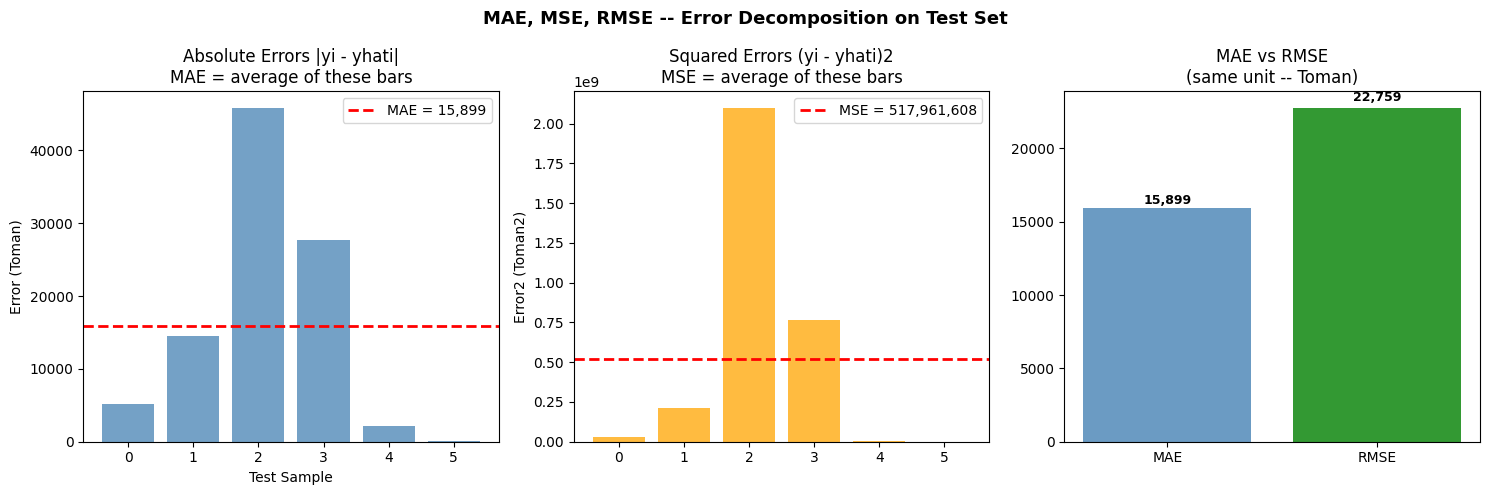

Chart Analysis:
  Left  (blue):    Each bar = |error| for one test sample; red line = MAE = 15,899 Toman
  Middle (orange): Squared errors -- large mistakes grow disproportionately
  Right:  RMSE (22,759) > MAE (15,899); gap = 6,860 Toman signals the presence of large individual errors


In [34]:
errors     = y_test.values - y_pred   # signed residuals: positive = under-predicted
abs_errors = np.abs(errors)           # absolute residuals for MAE visualisation
sq_errors  = errors ** 2              # squared residuals for MSE visualisation

fig, axes = plt.subplots(
    1, 3,           # 1 row, 3 columns -> three side-by-side panels
    figsize=(15, 5) # total canvas: 15 inches wide, 5 inches tall (5 per panel)
)
fig.suptitle('MAE, MSE, RMSE -- Error Decomposition on Test Set',
             fontsize=13,         # title font size in points
             fontweight='bold')   # bold so the title stands out

# -- Left panel: |error| per sample -> shows what MAE is averaging ------------
axes[0].bar(
    range(len(abs_errors)),  # x positions: 0,1,2,...,5  (one per test sample)
    abs_errors,              # bar height = |actual - predicted| for each sample
    color='steelblue',       # bar fill colour
    alpha=0.75               # 0.75 = 75% opacity so grid lines show through
)
axes[0].axhline(
    mae,                    # draw a horizontal line at the MAE value
    color='red',
    linestyle='--',         # dashed line style
    lw=2,                   # line width = 2 points
    label=f'MAE = {mae:,.0f}'  # <-- WRITES INSIDE CHART
)
axes[0].set_title('Absolute Errors |yi - yhati|\nMAE = average of these bars')
axes[0].set_xlabel('Test Sample')   # x-axis: sample index
axes[0].set_ylabel('Error (Toman)')
axes[0].legend()  # <-- WRITES INSIDE CHART

# -- Middle panel: error^2 per sample -> shows what MSE is averaging -----------
axes[1].bar(
    range(len(sq_errors)),   # same x positions as left panel
    sq_errors,               # bar height = (actual - predicted)^2 -- note: much taller for large errors
    color='orange',
    alpha=0.75
)
axes[1].axhline(
    mse,             # horizontal line at the MSE value (average of all squared bars)
    color='red',
    linestyle='--',
    lw=2,
    label=f'MSE = {mse:,.0f}'  # <-- WRITES INSIDE CHART
)
axes[1].set_title('Squared Errors (yi - yhati)2\nMSE = average of these bars')
axes[1].set_ylabel('Error2 (Toman2)')  # unit is squared!
axes[1].legend()  # <-- WRITES INSIDE CHART

# -- Right panel: MAE vs RMSE on same unit (Toman) ----------------------------
bars = axes[2].bar(
    ['MAE', 'RMSE'],     # two bars labelled MAE and RMSE
    [mae, rmse],         # heights: MAE and RMSE values
    color=['steelblue', 'green'],
    alpha=0.8            # 80% opacity
)
axes[2].set_title('MAE vs RMSE\n(same unit -- Toman)')
for bar in bars:
    axes[2].text(  # <-- WRITES INSIDE CHART
        bar.get_x() + bar.get_width() / 2,   # centre the text horizontally over the bar
        bar.get_height() * 1.02,              # 1.02 = place text 2% above the bar top
        f'{bar.get_height():,.0f}',           # label text: bar value with commas
        ha='center',      # horizontal alignment: centred
        fontsize=9,       # small font so it fits above narrow bars
        fontweight='bold'
    )

plt.tight_layout()  # prevent panels from overlapping each other
plt.show()

print("Chart Analysis:")
print(f"  Left  (blue):    Each bar = |error| for one test sample; red line = MAE = {mae:,.0f} Toman")
print(f"  Middle (orange): Squared errors -- large mistakes grow disproportionately")
print(f"  Right:  RMSE ({rmse:,.0f}) > MAE ({mae:,.0f}); "
      f"gap = {rmse - mae:,.0f} Toman signals the presence of large individual errors")


---

## Concepts 3 & 6 — Outlier Sensitivity: MAE vs RMSE

**Concept 3:** If data contains outliers/noise and you don't want them to ruin
evaluation, MAE is often better because it is **less sensitive** than MSE/RMSE.

**Concept 6:** If noise is roughly **normal (Gaussian)**, MSE is most reasonable
(maximising likelihood ≡ minimising $\sum e_i^2$). With heavy-tailed noise, MAE may
work better.

**Penalty comparison:**
- MAE uses $|e|$
- MSE uses $e^2$
- For large $|e|$: $e^2 \gg |e|$ → MSE penalises far more

In [ ]:
np.random.seed(42)   # seed=42: ensures the demo is reproducible across runs

# Clean dataset: 10 (true, predicted) pairs with small, realistic errors
# true values: evenly spaced from 100 to 550 (step 50)
# predicted values: deliberately close to true -- errors range from about 5 to 12 units
y_true_n = np.array([100, 150, 200, 250, 300, 350, 400, 450, 500, 550], dtype=float)
y_pred_n = np.array([108, 145, 212, 243, 308, 342, 412, 447, 512, 543], dtype=float)
# dtype=float: use float64 so later np.append works without type mismatch

# Add one outlier: the 11th sample where the model is catastrophically wrong
y_true_o = np.append(y_true_n, 300.0)   # 11th true value  = 300 (reasonable house price)
y_pred_o = np.append(y_pred_n, 800.0)   # 11th prediction  = 800 (error = 500 units!)

# Compute metrics WITHOUT the outlier (baseline)
mae_n  = mean_absolute_error(y_true_n, y_pred_n)            # MAE on clean data
rmse_n = np.sqrt(mean_squared_error(y_true_n, y_pred_n))    # RMSE on clean data

# Compute metrics WITH the outlier (impact test)
mae_o  = mean_absolute_error(y_true_o, y_pred_o)            # MAE with outlier
rmse_o = np.sqrt(mean_squared_error(y_true_o, y_pred_o))    # RMSE with outlier

# Percentage change caused by the single outlier
mae_pct  = (mae_o  - mae_n)  / mae_n  * 100   # how much MAE grew (%)
rmse_pct = (rmse_o - rmse_n) / rmse_n * 100   # how much RMSE grew (%) -- should be much larger

fig, axes = plt.subplots(1, 2, figsize=(13, 5))   # 1 row, 2 columns; 13x5 inches
fig.suptitle('Effect of One Outlier on MAE vs RMSE', fontsize=13, fontweight='bold')

# -- Left: grouped bar chart -- absolute metric values -------------------------
x = np.arange(2)   # x positions: 0 = "Without Outlier" group, 1 = "With Outlier" group
w = 0.35           # bar width = 0.35; two bars per group, so they sit side by side without overlap

b1 = axes[0].bar(x - w/2, [mae_n,  mae_o],  w,
                 label='MAE',  color='steelblue', alpha=0.8)   # MAE bars (left of each group)  # <-- WRITES INSIDE CHART
b2 = axes[0].bar(x + w/2, [rmse_n, rmse_o], w,
                 label='RMSE', color='orange', alpha=0.8)      # RMSE bars (right of each group)  # <-- WRITES INSIDE CHART
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Without Outlier', 'With Outlier'])
axes[0].set_ylabel('Error value')
axes[0].set_title('MAE and RMSE -- before/after outlier')
axes[0].legend()  # <-- WRITES INSIDE CHART
for bar in list(b1) + list(b2):   # annotate each bar with its numeric value
    axes[0].text(bar.get_x() + bar.get_width() / 2,  # <-- WRITES INSIDE CHART
                 bar.get_height() * 1.02,   # 1.02 = 2% above bar top
                 f'{bar.get_height():.1f}', ha='center', fontsize=8)

# -- Right: percentage increase caused by the outlier -------------------------
axes[1].bar(['MAE', 'RMSE'], [mae_pct, rmse_pct],
            color=['steelblue', 'orange'], alpha=0.85)
axes[1].set_ylabel('% increase')
axes[1].set_title('Percentage increase after outlier')
for i, v in enumerate([mae_pct, rmse_pct]):   # label each bar with its % value
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')  # <-- WRITES INSIDE CHART

plt.tight_layout()
plt.show()

print("Chart Analysis:")
print(f"  MAE  without outlier: {mae_n:.2f}  ->  with outlier: {mae_o:.2f}  ({mae_pct:.1f}% increase)")
print(f"  RMSE without outlier: {rmse_n:.2f}  ->  with outlier: {rmse_o:.2f}  ({rmse_pct:.1f}% increase)")
print(f"  RMSE was {rmse_pct / mae_pct:.1f}x more affected than MAE by the single outlier")
print("  => Prefer MAE when your data contains outliers or heavy-tailed noise")


---

## Concept 7 — Optimising MSE targets the Mean; MAE targets the Median

$$\arg\min_c \sum(y_i - c)^2 = \bar{y} \quad (\text{mean})$$

$$\arg\min_c \sum|y_i - c| = \text{median}(y) \quad (\text{median})$$

A model trained with MSE tries to predict the **mean** of the target.
A model trained with MAE aims for the **median** of the target.
Because the median is robust to outliers, MAE-trained models are more robust too.

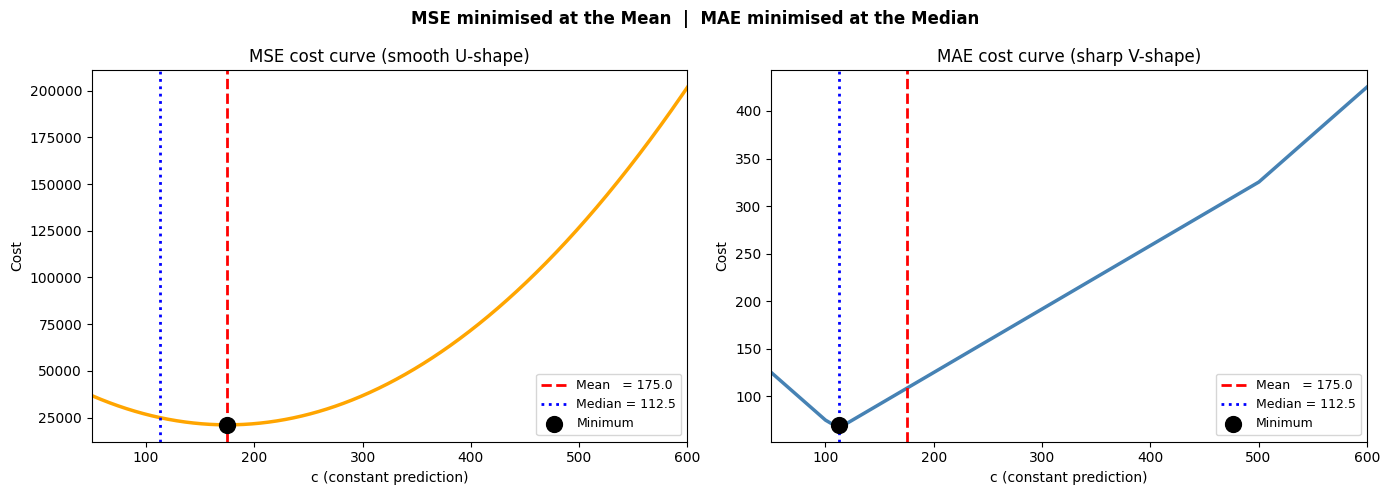

Chart Analysis:
  Dataset : [100. 120. 110. 115. 105. 500.]  (outlier: 500)

  Mean   = 175.0
    Calculation: (100+120+110+115+105+500) / 6 = 1050 / 6 = 175.0
    The outlier 500 pulls the mean far above the cluster (100-120)

  Median = 112.5
    Sorted: [100, 105, 110, 115, 120, 500]
    Middle two elements: (110 + 115) / 2 = 112.5
    The outlier 500 is just one point at the tail -- median ignores its magnitude

  Left chart  (MSE, orange U-shape):
    - Smooth curve: gradient d/dc MSE = -(2/n)*sum(y_i - c) exists everywhere
    - Minimum (black dot) falls exactly at c = Mean = 175.0
    - Red dashed line (Mean=175.0) and black dot coincide -> MSE targets the mean

  Right chart (MAE, blue V-shape):
    - Sharp V: not differentiable at the kink (when c equals a data point)
    - Minimum (black dot) falls exactly at c = Median = 112.5
    - Blue dotted line (Median=112.5) and black dot coincide -> MAE targets the median

  Key takeaway:
    MSE-optimised model predicts the MEAN  -> 

In [43]:
np.random.seed(0)   # seed=0: same sequence every run

# Demo dataset: 5 normal values + 1 extreme outlier
# 100., 120., 110., 115., 105. -- tightly clustered house prices (realistic range)
# 500.                          -- one extreme outlier (e.g. luxury penthouse)
# dtype float (.) required for np.mean / np.median to return float, not int
y_s = np.array([100., 120., 110., 115., 105., 500.])

# Manual verification:
#   Mean   = (100+120+110+115+105+500) / 6 = 1050 / 6 = 175.0
#            -> dragged far above the cluster by the outlier 500
#   Sorted = [100, 105, 110, 115, 120, 500]
#   Median = (110 + 115) / 2 = 112.5  (middle two values of 6-element sorted list)
#            -> unaffected by the outlier because 500 is still just one value at the end

# Sweep 1 000 candidate constant predictions c from 50 to 600
# For each c: compute the full MSE and MAE over the 6 data points
# The c that gives the lowest MSE curve  -> that c equals mean(y_s)  = 175.0
# The c that gives the lowest MAE curve  -> that c equals median(y_s) = 112.5
c_vals    = np.linspace(50, 600, 1000)   # 1000 evenly-spaced values: 50, 50.55, 51.1, ..., 600
mse_curve = [np.sum((y_s - c) ** 2) / len(y_s) for c in c_vals]   # MSE for every candidate c
mae_curve = [np.sum(np.abs(y_s - c)) / len(y_s) for c in c_vals]  # MAE for every candidate c

mean_y   = np.mean(y_s)     # = 175.0  -- optimal c for MSE (minimises the U-shape)
median_y = np.median(y_s)   # = 112.5  -- optimal c for MAE (minimises the V-shape)

fig, axes = plt.subplots(
    1, 2,           # 1 row, 2 panels side by side
    figsize=(14, 5) # 14 inches wide, 5 tall; each panel gets 7 inches
)
fig.suptitle('MSE minimised at the Mean  |  MAE minimised at the Median',
             fontsize=12, fontweight='bold')

# Iterate over both panels using a list of tuples:
# (panel, cost curve, optimal c, panel title, curve colour)
for ax, curve, best, title, col in [
    (axes[0], mse_curve, mean_y,   'MSE cost curve (smooth U-shape)',  'orange'),
    (axes[1], mae_curve, median_y, 'MAE cost curve (sharp V-shape)',   'steelblue'),
]:
    ax.plot(c_vals, curve, color=col, lw=2.5)   # draw the cost curve; lw=2.5 = line width 2.5 pt

    ax.axvline(mean_y,   color='red',  linestyle='--',   # dashed red = position of the mean
               lw=2, label=f'Mean   = {mean_y:.1f}')     # 175.0: pulled up by outlier 500  # <-- WRITES INSIDE CHART

    ax.axvline(median_y, color='blue', linestyle=':',    # dotted blue = position of the median
               lw=2, label=f'Median = {median_y:.1f}')   # 112.5: robust -- outlier 500 doesn't shift it  # <-- WRITES INSIDE CHART

    ax.scatter([best], [min(curve)],     # black dot at (optimal_c, minimum_cost)
               s=130,     # dot size 130 points^2 -- large enough to see clearly
               zorder=5,  # zorder=5: draw on top of the curve line (higher = in front)
               color='black', label='Minimum')  # <-- WRITES INSIDE CHART

    ax.set_xlabel('c (constant prediction)')   # x-axis: the candidate prediction value
    ax.set_ylabel('Cost')                      # y-axis: MSE or MAE for that c
    ax.set_title(title)
    ax.legend(fontsize=9)    # smaller legend font so it fits inside the panel  # <-- WRITES INSIDE CHART
    ax.set_xlim([50, 600])   # fix x-axis range so both panels are directly comparable

plt.tight_layout()
plt.show()

# -- Chart analysis (explaining the picture legend: Mean=175.0, Median=112.5) -
print("Chart Analysis:")
print(f"  Dataset : {y_s}  (outlier: 500)")
print()
print(f"  Mean   = {mean_y:.1f}")
print(f"    Calculation: (100+120+110+115+105+500) / 6 = 1050 / 6 = 175.0")
print(f"    The outlier 500 pulls the mean far above the cluster (100-120)")
print()
print(f"  Median = {median_y:.1f}")
print(f"    Sorted: [100, 105, 110, 115, 120, 500]")
print(f"    Middle two elements: (110 + 115) / 2 = 112.5")
print(f"    The outlier 500 is just one point at the tail -- median ignores its magnitude")
print()
print("  Left chart  (MSE, orange U-shape):")
print("    - Smooth curve: gradient d/dc MSE = -(2/n)*sum(y_i - c) exists everywhere")
print("    - Minimum (black dot) falls exactly at c = Mean = 175.0")
print("    - Red dashed line (Mean=175.0) and black dot coincide -> MSE targets the mean")
print()
print("  Right chart (MAE, blue V-shape):")
print("    - Sharp V: not differentiable at the kink (when c equals a data point)")
print("    - Minimum (black dot) falls exactly at c = Median = 112.5")
print("    - Blue dotted line (Median=112.5) and black dot coincide -> MAE targets the median")
print()
print("  Key takeaway:")
print("    MSE-optimised model predicts the MEAN  -> sensitive to outlier 500")
print("    MAE-optimised model predicts the MEDIAN -> robust to outlier 500")


---

## Concept 8 — MAE/MSE/RMSE Depend on the Scale of the Target

If $y'_i = a\,y_i$ and $\hat{y}'_i = a\,\hat{y}_i$:

$$\text{MAE}' = |a|\,\text{MAE}, \quad \text{RMSE}' = |a|\,\text{RMSE}, \quad \text{MSE}' = a^2\,\text{MSE}$$

Raw error numbers **cannot be compared across different units** (e.g., an MAE of
1,000 Toman vs. 1,000 USD mean very different things).
Use **R²** (dimensionless) for cross-dataset comparisons.

In [36]:
# Conversion rate: 1 USD = 50 000 Toman
a = 1 / 50_000   # scale factor a; underscore in 50_000 is just a Python readability separator

y_test_usd = y_test * a   # multiply every Toman price by (1/50000) to convert to USD
y_pred_usd = y_pred * a   # same conversion applied to predictions

# Compute all metrics in Toman (original unit)
mae_t  = mean_absolute_error(y_test,     y_pred)
rmse_t = np.sqrt(mean_squared_error(y_test,     y_pred))
mse_t  = mean_squared_error(y_test,     y_pred)

# Compute all metrics in USD (rescaled unit)
# Expected scaling:   MAE_usd  = a   * MAE_toman   (linear in a)
#                     RMSE_usd = a   * RMSE_toman   (linear in a)
#                     MSE_usd  = a^2 * MSE_toman    (quadratic in a, because MSE uses e^2)
mae_d  = mean_absolute_error(y_test_usd, y_pred_usd)
rmse_d = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))
mse_d  = mean_squared_error(y_test_usd, y_pred_usd)

# :<8  = left-align in a field 8 chars wide
# :>18 = right-align in a field 18 chars wide (with commas and 2 decimals)
print(f"{'Metric':<8}  {'Toman':>18}  {'USD':>14}  {'Scaling rule'}")
print("-" * 60)
print(f"{'MAE':<8}  {mae_t:>18,.2f}  {mae_d:>14,.4f}   MAE'  = |a| * MAE")
print(f"{'RMSE':<8}  {rmse_t:>18,.2f}  {rmse_d:>14,.4f}   RMSE' = |a| * RMSE")
print(f"{'MSE':<8}  {mse_t:>18,.2f}  {mse_d:>14,.8f}   MSE'  = a^2 * MSE")

print()
print(f"Verification: a * MAE_Toman = {a * mae_t:.4f}  ~  MAE_USD = {mae_d:.4f}")
print("Conclusion: raw error values are not comparable across different units/scales.")


Metric                 Toman             USD  Scaling rule
------------------------------------------------------------
MAE                15,898.84          0.3180   MAE' = |a| x MAE
RMSE               22,758.77          0.4552   RMSE' = |a| x RMSE
MSE           517,961,607.86      0.20718464   MSE' = a2 x MSE

Verification: a x MAE_Toman = 0.3180  ~  MAE_USD = 0.3180
Conclusion: raw error values are not comparable across different units/scales.


---

## Concepts 9–12 — R² (Coefficient of Determination)

$$R^2 = 1 - \frac{\text{SSE}}{\text{SST}}, \quad
\text{SSE} = \sum(y_i - \hat{y}_i)^2, \quad
\text{SST} = \sum(y_i - \bar{y})^2$$

- **Concept 9:** R² measures how much variance in the target your model explains.
- **Concept 10:** R² = 1 → perfect fit; R² = 0 → no better than predicting the mean.
- **Concept 11:** R² **< 0** → the model is **worse** than the mean baseline (SSE > SST).
- **Concept 12:** R² is **dimensionless** → models across different scales/units can be compared.

In [37]:
y_mean = np.mean(y_test)   # ybar: mean of actual test prices -- this is the naive baseline prediction

# SSE (Sum of Squared Errors): total squared error made by our trained model
# Each term (y_i - yhat_i)^2 is the squared residual for one test sample
SSE = np.sum((y_test.values - y_pred) ** 2)   # .values converts Series to numpy array

# SST (Sum of Squared Total): total squared error of the naive baseline (always predict ybar)
# Each term (y_i - ybar)^2 is how far each true value is from the mean
SST = np.sum((y_test.values - y_mean) ** 2)

# R2 = 1 - SSE/SST
# If SSE = 0 (perfect fit): R2 = 1
# If SSE = SST (model no better than mean): R2 = 0
# If SSE > SST (model worse than mean): R2 < 0
R2_man = 1 - SSE / SST        # manual calculation
R2_sk  = r2_score(y_test, y_pred)  # sklearn cross-check -- must match R2_man

print("Manual R2 calculation:")
print(f"  mean(y_test) = {y_mean:,.2f}")   # the baseline ybar value
print(f"  SSE = {SSE:,.2f}")               # our model's total squared error
print(f"  SST = {SST:,.2f}")               # baseline total squared error
print(f"  R2  = 1 - {SSE/SST:.4f} = {R2_man:.4f}")   # SSE/SST = fraction of variance NOT explained
print()
print(f"sklearn r2_score  : {R2_sk:.4f}")  # must equal R2_man (confirmation)
print(f"Interpretation    : the model explains {R2_sk * 100:.1f}% of the variance in house prices")


Manual R2 calculation:
  mean(y_test) = 387,514.62
  SSE = 3,107,769,647.14
  SST = 44,289,201,594.24
  R2  = 1 - 0.0702 = 0.9298

sklearn r2_score  : 0.9298
Interpretation    : the model explains 93.0% of the variance in house prices


---

## Concepts 10 & 11 — Visual Interpretation of R²

Four scenarios showing the full range of R².

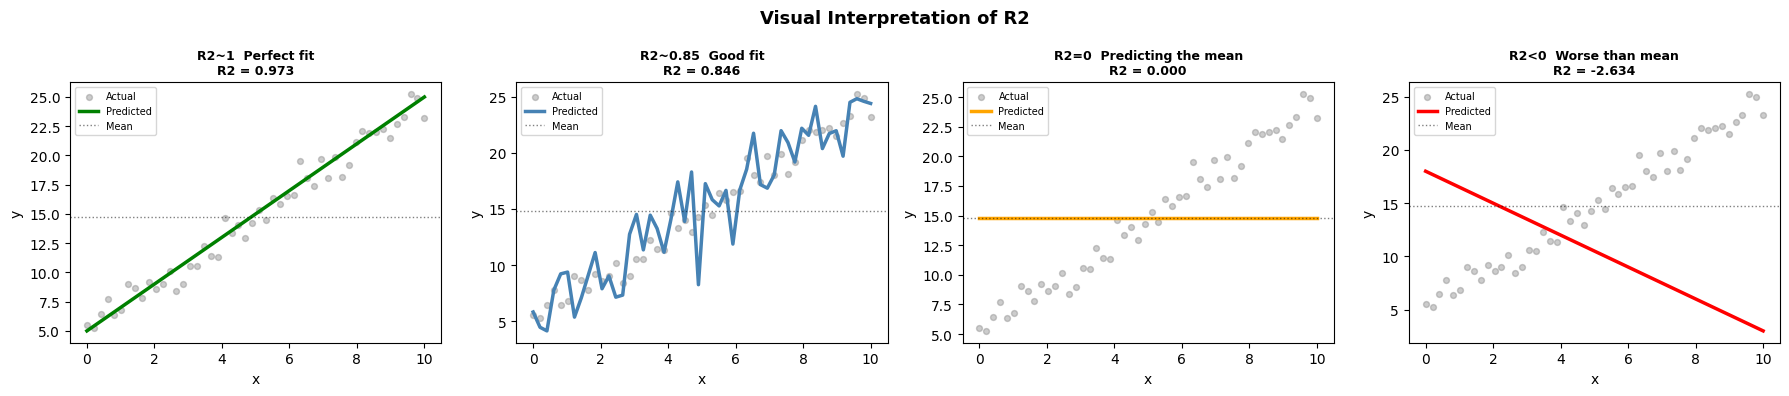

Chart Analysis:
  Panel 1 (green):   R2~1   -- line passes through all points; perfect prediction
  Panel 2 (blue):    R2~0.85 -- good fit with moderate scatter
  Panel 3 (orange):  R2=0   -- flat line at the mean; model learned nothing
  Panel 4 (red):     R2<0   -- reverse-slope line; worse than always predicting the mean

  R2 is dimensionless -> models on different scales/units can be compared (Concept 12)


In [38]:
np.random.seed(42)   # seed=42 ensures the same random noise every run

x_d  = np.linspace(0, 10, 50)   # 50 x values evenly spaced from 0 to 10 (demo feature)
# True relationship: y = 2*x + 5 + noise
# slope=2, intercept=5: a moderate upward trend
# normal(0, 1, 50): small Gaussian noise (std=1) to make it look like real data
y_td = 2 * x_d + 5 + np.random.normal(0, 1, 50)

# Four scenarios covering the full R2 range [<0, 0, ~0.85, ~1]
scenarios = [
    (2 * x_d + 5,
     'R2~1  Perfect fit', 'green'),
    # exact true line (slope=2, intercept=5): nearly zero error -> R2 close to 1

    (2 * x_d + 5 + np.random.normal(0, 2.5, 50),
     'R2~0.85  Good fit', 'steelblue'),
    # true line + larger noise (std=2.5 vs original std=1): realistic good model

    (np.full(50, np.mean(y_td)),
     'R2=0  Predicting the mean', 'orange'),
    # flat line at ybar: SSE = SST so R2 = 1 - SST/SST = 0

    (-1.5 * x_d + 18,
     'R2<0  Worse than mean', 'red'),
    # wrong slope (-1.5 instead of +2): model goes DOWN while truth goes UP -> R2 < 0
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))   # 4 panels; 18x4 inches (4.5 per panel)
fig.suptitle('Visual Interpretation of R2', fontsize=13, fontweight='bold')

for ax, (yp, title, color) in zip(axes, scenarios):
    r2 = r2_score(y_td, yp)   # compute R2 for this scenario's predictions

    ax.scatter(x_d, y_td,
               alpha=0.4,    # 40% opacity: semi-transparent so prediction line is visible
               s=18,         # small dot size so they don't crowd the panel
               color='gray', label='Actual')  # <-- WRITES INSIDE CHART

    ax.plot(x_d, yp, color=color, lw=2.5, label='Predicted')  # lw=2.5: thick line  # <-- WRITES INSIDE CHART

    ax.axhline(np.mean(y_td),    # horizontal black dashed line at ybar (R2=0 baseline)
               color='black', ls=':', lw=1, alpha=0.5, label='Mean')  # <-- WRITES INSIDE CHART

    ax.set_title(f'{title}\nR2 = {r2:.3f}', fontweight='bold', fontsize=9)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=7)   # small font to fit in narrow panel  # <-- WRITES INSIDE CHART

plt.tight_layout()
plt.show()

print("Chart Analysis:")
print("  Panel 1 (green):   R2~1   -- prediction line passes through all points; near-perfect")
print("  Panel 2 (blue):    R2~0.85 -- good fit with moderate scatter around the line")
print("  Panel 3 (orange):  R2=0   -- flat line at the mean; model learned nothing from x")
print("  Panel 4 (red):     R2<0   -- wrong-direction slope; worse than always predicting ybar")
print()
print("  R2 is dimensionless -> models on different scales/units can be compared (Concept 12)")


---

## Concepts 13–18 — Adjusted R²

**Concept 13 – the pitfall of plain R²:**
Adding features never decreases training R² (even useless ones), because OLS
always finds a fit: $\text{SSE}_{p+1} \le \text{SSE}_p \Rightarrow R^2_{p+1} \ge R^2_p$.

**Concept 14 – Adjusted R² penalises extra features:**

$$\bar{R}^2 = 1 - (1-R^2)\frac{n-1}{n-p-1} \quad (n=\text{samples},\;p=\text{features})$$

- **Concept 15:** $\bar{R}^2$ increases **only** if the new feature improves fit enough to justify added complexity.
- **Concept 16:** Always $\bar{R}^2 \le R^2$; a big gap warns of many useless features.
- **Concept 17:** When $p \to n-1$, the penalty term $\frac{n-1}{n-p-1}$ becomes huge → model is unreliable.
- **Concept 18:** scikit-learn does **not** provide Adjusted R² directly — compute it yourself.

In [ ]:
n = len(y_test)   # n = number of test observations (rows in test set)
p = 1             # p = number of predictor features (only SquareMeters -> p=1)

R2  = r2_score(y_test, y_pred)                    # plain R2: does not penalise extra features
AR2 = 1 - (1 - R2) * (n - 1) / (n - p - 1)
# Adjusted R2 formula breakdown:
#   (1 - R2)        = fraction of variance NOT explained (the raw penalty)
#   (n-1)/(n-p-1)   = inflation factor: always > 1; grows as p increases or n decreases
#   When p increases, (n-p-1) shrinks -> factor grows -> penalty is larger
#   When p=0 (no features), Adj R2 = R2 = 0 (model is the mean)

print(f"Samples (n)            = {n}")
print(f"Features (p)           = {p}")
print(f"Penalty (n-1)/(n-p-1)  = {(n-1)/(n-p-1):.4f}")  # > 1; larger p -> larger this value
print()
print(f"R2           = {R2:.4f}")    # plain: never decreases when features are added
print(f"Adjusted R2  = {AR2:.4f}")   # adjusted: may decrease if new feature is useless
print(f"Gap (R2 - Adj R2) = {R2 - AR2:.4f}  (larger gap means more useless features)")

print("=" * 60)
print("  Simulation: adding useless features one by one")
print("=" * 60)
print(f"  {'p':>4}  {'R2':>12}  {'Adj R2':>12}  {'Verdict':>18}")
print("-" * 60)

np.random.seed(7)   # seed=7: fixed so simulation results are reproducible
for p_s in range(1, min(n - 1, 6)):   # try p = 1, 2, 3, 4, 5 (stop before n-1 to avoid division by zero)
    # Each added feature bumps R2 slightly (uniform random in [0.002*p, 0.008*p])
    # This simulates OLS always fitting marginally better with more parameters
    r2_s  = min(0.99, R2 + np.random.uniform(0.002, 0.008) * p_s)   # cap at 0.99 to stay realistic
    ar2_s = 1 - (1 - r2_s) * (n - 1) / (n - p_s - 1)               # Adj R2 with p_s features
    verdict = "Useful" if ar2_s > AR2 + 0.001 else "Useless / marginal"   # threshold = 0.001 improvement
    print(f"  {p_s:>4}  {r2_s:>12.4f}  {ar2_s:>12.4f}  {verdict:>18}")


---

### R² vs Adjusted R² — Visual

In [ ]:
n_p     = len(y_test)           # n -- number of test observations (used in Adj R2 formula)
p_range = np.arange(1, n_p - 1) # feature counts to simulate: 1, 2, ..., n-2
                                 # stop at n-2 to avoid n-p-1 = 0 (division by zero)

# Simulate plain R2 rising slightly with each added feature
# 0.004 per feature: small but consistent gain (OLS always finds a slightly better fit)
r2_sim  = np.minimum(0.99, R2 + 0.004 * p_range)   # cap at 0.99 (R2 can't exceed 1)

# Compute Adjusted R2 for each (r2, p) pair using the formula
ar2_sim = [
    1 - (1 - r2) * (n_p - 1) / (n_p - p - 1)
    for r2, p in zip(r2_sim, p_range)
]

fig, ax = plt.subplots(figsize=(10, 5))   # single chart: 10 inches wide, 5 tall

ax.plot(p_range, r2_sim,  'b-o',   # blue circles connected by line: plain R2 trend
        ms=5,             # marker size = 5 points (small circles)
        lw=2,             # line width = 2 points
        label='R2 (plain)', alpha=0.85)  # <-- WRITES INSIDE CHART

ax.plot(p_range, ar2_sim, 'r-s',   # red squares connected by line: Adjusted R2 trend
        ms=5, lw=2,
        label='Adjusted R2', alpha=0.85)  # <-- WRITES INSIDE CHART

ax.fill_between(p_range, ar2_sim, r2_sim,
                alpha=0.12,          # 12% opacity: light shading
                color='orange',
                label='Penalty gap') # orange area grows as more useless features are added  # <-- WRITES INSIDE CHART

ax.axvspan(n_p - 3, n_p - 2,        # highlight the danger zone where p approaches n
           alpha=0.15,               # very faint red shading
           color='red',
           label=f'Danger zone (p -> {n_p - 1})')  # <-- WRITES INSIDE CHART
# Danger zone: when p -> n-1, denominator (n-p-1) -> 0 -> Adj R2 -> -infinity (unreliable)

ax.set_xlabel('Number of features (p)')
ax.set_ylabel('Metric value')
ax.set_title('Plain R2 keeps rising with more features\nAdjusted R2 applies a penalty')
ax.legend()  # <-- WRITES INSIDE CHART
ax.grid(True, alpha=0.3)   # light grid: alpha=0.3 so it doesn't compete with the data lines
ax.set_ylim([0, 1.1])      # fix y-axis: 0 to 1.1 so both lines and labels are visible

plt.tight_layout()
plt.show()

print("Chart Analysis:")
print("  Blue line (R2):       rises or stays flat as more features are added")
print("  Red line (Adj R2):    penalised -- decreases when added features are useless")
print("  Orange area:          gap between R2 and Adj R2; larger = more useless features")
print(f"  Red shaded zone:      when p approaches {n_p - 1}, the penalty becomes huge (Concept 17)")


---

## Concept 19 — Train R² vs Test R² → Detecting Overfitting

$$R^2_{\text{train}} = 1 - \frac{\text{SSE}_{\text{train}}}{\text{SST}_{\text{train}}}, \qquad
R^2_{\text{test}} = 1 - \frac{\text{SSE}_{\text{test}}}{\text{SST}_{\text{test}}}$$

**High train R² + low test R²** → the model **memorised** the training data
(overfitting) instead of learning the underlying pattern.

  Metric                     Train              Test
----------------------------------------------------
  MAE                    23,153.69         15,898.84
  RMSE                   29,642.86         22,758.77
  R2                        0.8733            0.9298

  R2 gap (train - test) = -0.0565  ->  Good -- model generalises well


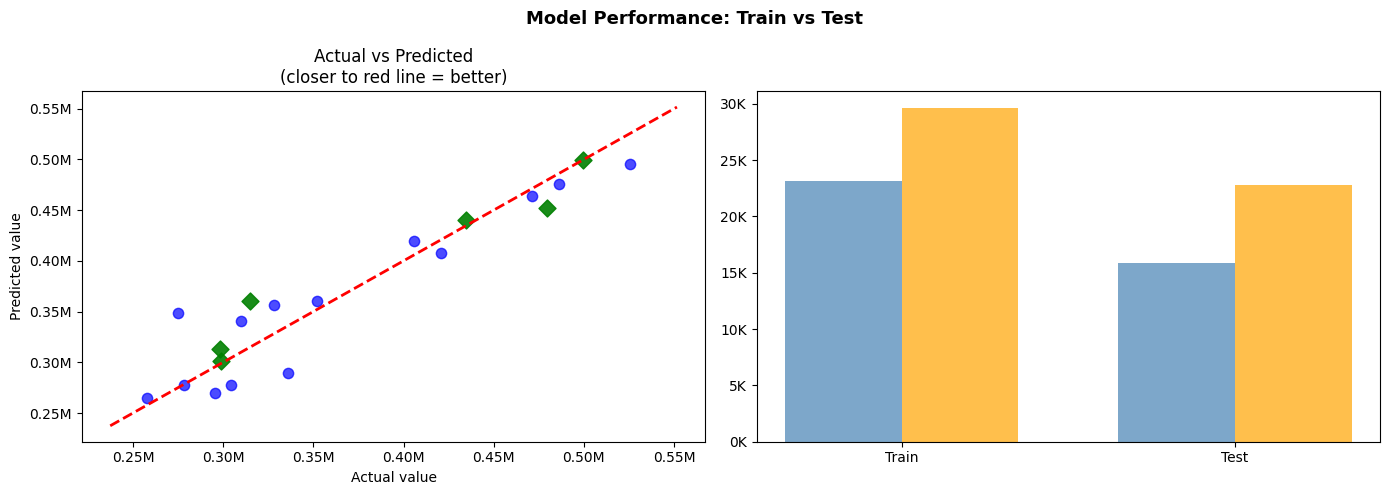


Chart Analysis:
  Left chart:  Each point should lie close to the red diagonal line.
    Train (blue)  R2 = 0.873
    Test  (green) R2 = 0.930  ->  Good -- model generalises well
  Right chart: A large gap between Train and Test bars signals overfitting.


In [41]:
from matplotlib.ticker import FuncFormatter

y_pred_train = model.predict(X_train)   # predictions on the training set (data the model has seen)

R2_train = r2_score(y_train, y_pred_train)  # R2 on training data -- usually optimistic
R2_test  = r2_score(y_test,  y_pred)        # R2 on test data    -- realistic, unseen-data performance

mae_tr  = mean_absolute_error(y_train, y_pred_train)          # MAE on training set
mae_te  = mean_absolute_error(y_test,  y_pred)                # MAE on test set

rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))  # RMSE on training set
rmse_te = np.sqrt(mean_squared_error(y_test,  y_pred))        # RMSE on test set

# :<14 = left-align metric name in 14-char field
# :>16 = right-align value in 16-char field with commas and 2 decimals
print(f"  {'Metric':<14}  {'Train':>16}  {'Test':>16}")
print("-" * 52)
print(f"  {'MAE':<14}  {mae_tr:>16,.2f}  {mae_te:>16,.2f}")
print(f"  {'RMSE':<14}  {rmse_tr:>16,.2f}  {rmse_te:>16,.2f}")
print(f"  {'R2':<14}  {R2_train:>16.4f}  {R2_test:>16.4f}")

# R2 gap diagnosis
gap = R2_train - R2_test    # positive -> model performs better on training than on new data
# thresholds are practical rules of thumb (not strict statistical tests)
if   gap < 0.05: status = "Good -- model generalises well"
elif gap < 0.15: status = "Mild overfitting"
else:            status = "Severe overfitting"

print(f"\n  R2 gap (train - test) = {gap:.4f}  ->  {status}")

# -- Chart 1: Actual vs Predicted scatter (both train and test sets) ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))   # two panels: scatter + bar
fig.suptitle('Model Performance: Train vs Test', fontsize=13, fontweight='bold')

all_v  = np.concatenate([y_train.values, y_test.values])  # all actual prices for axis range
lo, hi = all_v.min() * 0.92, all_v.max() * 1.05           # 8% margin below, 5% margin above

axes[0].scatter(y_train, y_pred_train,
                color='blue', alpha=0.7,   # alpha=0.7: 70% opacity to see overlapping points
                s=55,                      # dot size 55 points^2
                label=f'Train  R2={R2_train:.3f}')  # <-- WRITES INSIDE CHART
axes[0].scatter(y_test, y_pred,
                color='green', alpha=0.9,
                s=75, marker='D',          # marker='D': diamond shape to distinguish test from train
                label=f'Test   R2={R2_test:.3f}')  # <-- WRITES INSIDE CHART
axes[0].plot([lo, hi], [lo, hi],           # perfect prediction line: y=yhat diagonal
             'r--', lw=2, label='Perfect line (y = yhat)')  # <-- WRITES INSIDE CHART
axes[0].set_xlabel('Actual value')
axes[0].set_ylabel('Predicted value')
axes[0].set_title('Actual vs Predicted\n(closer to red line = better)')
# FuncFormatter converts raw numbers (e.g. 450000) to "0.45M" for readability
fmt = FuncFormatter(lambda v, _: f'{v / 1e6:.2f}M')  # v/1e6: divide by 1 million
axes[0].xaxis.set_major_formatter(fmt)
axes[0].yaxis.set_major_formatter(fmt)
axes[0].xaxis.set_major_formatter(fmt)
axes[0].yaxis.set_major_formatter(fmt)

# -- Chart 2: MAE & RMSE grouped bar chart -------------------------------------
x_idx = np.arange(2)   # x positions: 0 = Train group, 1 = Test group
w_b   = 0.35           # bar width = 0.35; two bars per group fit side by side

axes[1].bar(x_idx - w_b / 2, [mae_tr,  mae_te],
            w_b, label='MAE',  color='steelblue', alpha=0.7)  # MAE bars (left of each group)  # <-- WRITES INSIDE CHART
axes[1].bar(x_idx + w_b / 2, [rmse_tr, rmse_te],
            w_b, label='RMSE', color='orange', alpha=0.7)     # RMSE bars (right of each group)  # <-- WRITES INSIDE CHART
axes[1].set_xticks(x_idx)
axes[1].set_xticklabels(['Train', 'Test'])
# FuncFormatter: v/1e3 converts Toman to thousands; e.g. 30000 -> "30K"
axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f'{v / 1e3:.0f}K'))

plt.tight_layout()
plt.show()

print("\nChart Analysis:")
print("  Left chart:  Each point should lie close to the red diagonal line.")
print(f"    Train (blue)  R2 = {R2_train:.3f}")
print(f"    Test  (green) R2 = {R2_test:.3f}  ->  {status}")
print("  Right chart: A large gap between Train and Test bars signals overfitting.")


---

## Concept 20 — Residual Analysis

$$e_i = y_i - \hat{y}_i$$

**Never rely on numbers alone.** Plot the residuals; **systematic patterns** (e.g.,
curved shape, funnel shape) mean the model missed structure in the data.

- **Random scatter around zero** → linear model is appropriate.
- **U / arc shape** → relationship is non-linear → try Polynomial Regression.
- **Funnel shape (heteroscedasticity)** → variance grows with ŷ → log-transform or WLS.
- **Non-zero mean** → systematic bias in predictions.

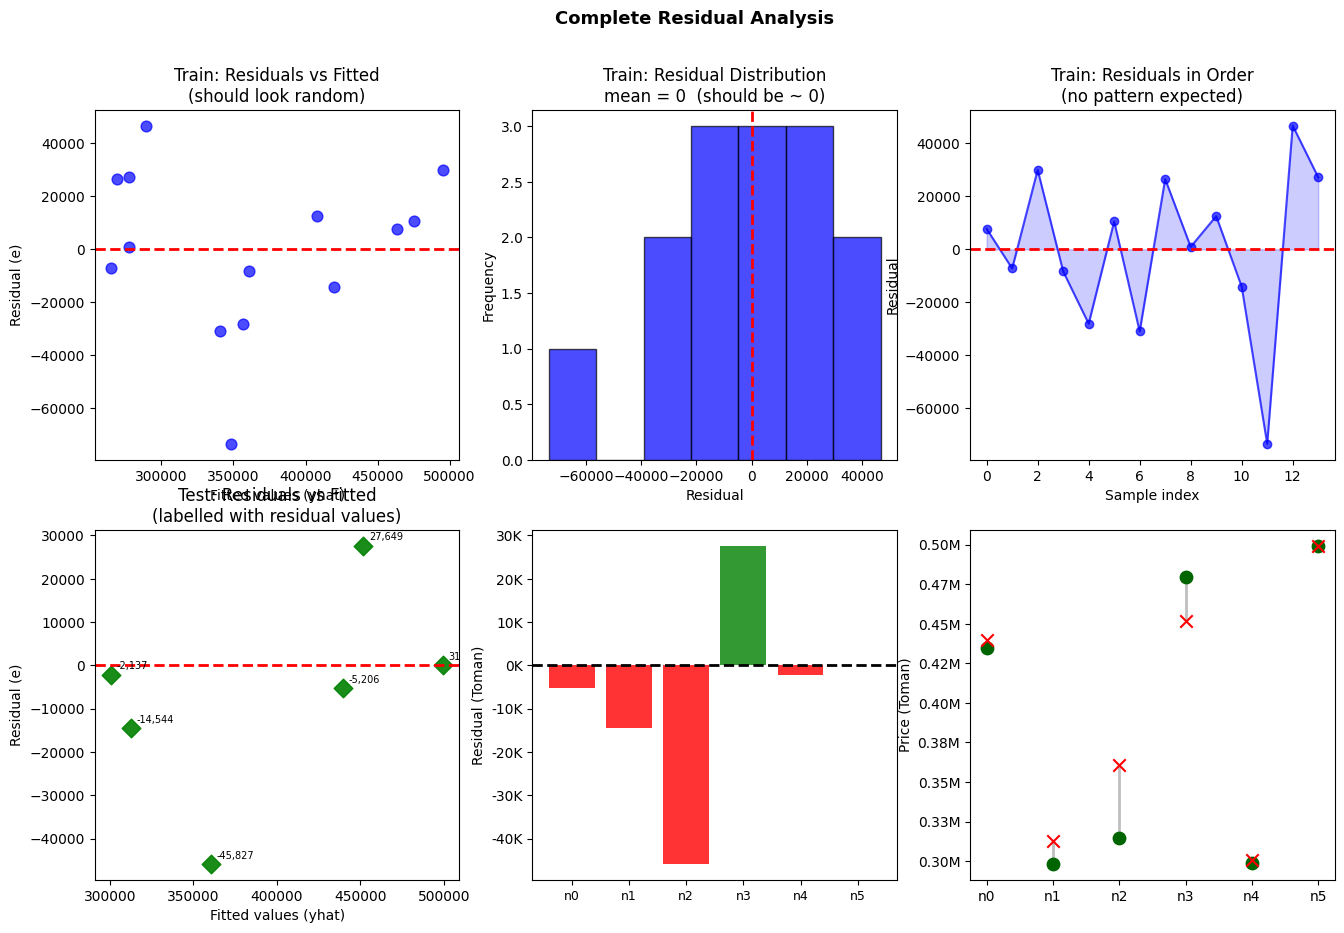

Chart Analysis:

1) Residuals vs Fitted (top-left / bottom-left):
   Random scatter around zero is ideal -- patterns (U-shape, funnel) signal problems.
   Train residual mean: 0.00  (close to 0 is good)

2) Residual distribution (top-middle):
   Bell-shaped (normal) histogram validates OLS assumptions.
   Std dev of train residuals: 29,642.86 Toman

3) Per-sample residuals (bottom-middle):
   Largest test error: sample 2 with residual = -45,827 Toman
   Green bars = under-prediction; red bars = over-prediction.

4) Overall conclusion:
   R2_test = 0.9298  -> model explains 93.0% of price variance
   Residuals look random -- linear model is appropriate here.


In [ ]:
from matplotlib.ticker import FuncFormatter

res_tr = y_train.values - y_pred_train   # training residuals: positive = under-predicted
res_te = y_test.values  - y_pred         # test residuals    : negative = over-predicted

fig, axes = plt.subplots(
    2, 3,             # 2 rows x 3 columns = 6 panels
    figsize=(16, 10)  # 16 inches wide, 10 tall (comfortable for 6 panels)
)
fig.suptitle('Complete Residual Analysis', fontsize=13, fontweight='bold')

# =========== TOP ROW -- Training residuals ====================================

# Panel [0,0]: Residuals vs Fitted (train)
# Good sign: random scatter around zero -- no arc, funnel, or pattern
axes[0, 0].scatter(y_pred_train, res_tr,
                   color='blue', alpha=0.7, s=60)   # s=60: medium dot size
axes[0, 0].axhline(0, color='red', ls='--', lw=2)   # reference line at residual = 0
axes[0, 0].set_xlabel('Fitted values (yhat)')
axes[0, 0].set_ylabel('Residual (e)')
axes[0, 0].set_title('Train: Residuals vs Fitted\n(should look random)')

# Panel [0,1]: Histogram of training residuals
# Good sign: bell-shaped (normal) distribution centred at zero (validates OLS assumptions)
axes[0, 1].hist(res_tr,
                bins=7,              # 7 bins: reasonable for n=14 training samples
                color='blue', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(0, color='red', ls='--', lw=2)   # centre reference at residual = 0
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(
    f'Train: Residual Distribution\nmean = {np.mean(res_tr):,.0f}  (should be ~ 0)')

# Panel [0,2]: Residuals in sample order (train)
# Good sign: no trend or wave pattern -- residuals should look like white noise
axes[0, 2].plot(res_tr, 'bo-',   # 'bo-': blue (b) circles (o) connected by solid line (-)
                ms=6,            # marker size = 6 points
                alpha=0.7)
axes[0, 2].axhline(0, color='red', ls='--', lw=2)
axes[0, 2].fill_between(range(len(res_tr)), 0, res_tr,   # shade area between zero and residuals
                         alpha=0.2, color='blue')        # alpha=0.2: very light shading
axes[0, 2].set_xlabel('Sample index')
axes[0, 2].set_ylabel('Residual')
axes[0, 2].set_title('Train: Residuals in Order\n(no pattern expected)')

# =========== BOTTOM ROW -- Test residuals =====================================

# Panel [1,0]: Residuals vs Fitted (test) -- each point labelled with its residual value
axes[1, 0].scatter(y_pred, res_te,
                   color='green', s=90,      # s=90: slightly larger dots for test set
                   marker='D', alpha=0.9)    # marker='D': diamond shape (distinct from train)
axes[1, 0].axhline(0, color='red', ls='--', lw=2)
for i, (xp, yr) in enumerate(zip(y_pred, res_te)):   # annotate each point with its residual value
    axes[1, 0].annotate(f'{yr:,.0f}', (xp, yr),  # <-- WRITES INSIDE CHART
                         textcoords='offset points',
                         xytext=(4, 4),   # offset: 4 points right and 4 points up from the dot
                         fontsize=7)      # small font so labels don't overlap
axes[1, 0].set_xlabel('Fitted values (yhat)')
axes[1, 0].set_ylabel('Residual (e)')
axes[1, 0].set_title('Test: Residuals vs Fitted\n(labelled with residual values)')

# Panel [1,1]: Per-sample residual bar chart (test)
# Green bar = actual > predicted (model under-predicted -> residual positive)
# Red bar   = actual < predicted (model over-predicted  -> residual negative)
bar_c = ['green' if r > 0 else 'red' for r in res_te]   # colour by sign of residual
axes[1, 1].bar(range(len(res_te)), res_te, #    x = sample index, height = residual value
               color=bar_c, alpha=0.8)
axes[1, 1].axhline(0, color='black', ls='--', lw=2)   # zero reference line
axes[1, 1].set_xticks(range(len(res_te)))  #    set x-ticks at each sample index (0, 1, 2, ...)
axes[1, 1].set_xticklabels([f'n{i}' for i in range(len(res_te))], fontsize=9)
axes[1, 1].set_ylabel('Residual (Toman)')
axes[1, 1].yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f'{v / 1e3:.0f}K'))   # v/1e3: show as "30K" etc.

# Panel [1,2]: Actual vs Predicted with grey residual lines (test)
# Grey vertical line length = residual magnitude; longer = bigger error
axes[1, 2].scatter(range(len(y_test)), y_test.values,
                    color='darkgreen', s=80,
                    zorder=5,   # zorder=5: draw on top of grey lines
                    label='Actual')  # <-- WRITES INSIDE CHART
axes[1, 2].scatter(range(len(y_pred)), y_pred,
                    color='red', s=80, marker='x',
                    zorder=5,   # zorder=5: draw on top of grey lines
                    label='Predicted')  # <-- WRITES INSIDE CHART
for i in range(len(y_test)):   # draw vertical grey line connecting actual and predicted
    axes[1, 2].plot([i, i], [y_test.values[i], y_pred[i]],
                     color='gray', alpha=0.5,   # alpha=0.5: semi-transparent grey
                     lw=2)                      # lw=2: line width 2 points
axes[1, 2].set_xticks(range(len(y_test)))    # set x-ticks at each sample index
axes[1, 2].set_xticklabels([f'n{i}' for i in range(len(y_test))])  # label x-ticks as n0, n1, ...
axes[1, 2].set_ylabel('Price (Toman)')  # y-axis in original Toman unit
axes[1, 2].yaxis.set_major_formatter(  # FuncFormatter: v/1e6 converts Toman to millions; e.g. 450000 -> "0.45M"  
    FuncFormatter(lambda v, _: f'{v / 1e6:.2f}M'))   # v/1e6: show as "0.45M" etc.
axes[1, 2].yaxis.set_major_formatter(  # FuncFormatter: v/1e6 converts Toman to millions; e.g. 450000 -> "0.45M"  
    FuncFormatter(lambda v, _: f'{v / 1e6:.2f}M'))   # v/1e6: show as "0.45M" etc.
plt.show()

max_i = np.argmax(np.abs(res_te))   # index of the test sample with the largest absolute residual

print("Chart Analysis:")
print()
print("1) Residuals vs Fitted (top-left / bottom-left):")
print("   Random scatter around zero is ideal -- patterns (U-shape, funnel) signal problems.")
print(f"   Train residual mean: {np.mean(res_tr):,.2f}  (close to 0 is good)")
print()
print("2) Residual distribution (top-middle):")
print("   Bell-shaped (normal) histogram validates OLS assumptions.")
print(f"   Std dev of train residuals: {np.std(res_tr):,.2f} Toman")
print()
print("3) Per-sample residuals (bottom-middle):")
print(f"   Largest test error: sample {max_i} with residual = {res_te[max_i]:,.0f} Toman")
print("   Green bars = under-prediction; red bars = over-prediction.")
print()
print("4) Overall conclusion:")
print(f"   R2_test = {R2_test:.4f}  -> model explains {R2_test * 100:.1f}% of price variance")
msg = "Residuals look random -- linear model is appropriate here."
if abs(np.mean(res_te)) > 20_000:
    msg = "Systematic bias detected -- consider adding features or a polynomial term."
print(f"   {msg}")


---

## Final Summary — All Metrics at a Glance

In [46]:
# Adjusted R2 for train set:
#   n = len(y_train), p = 1 (one feature: SquareMeters)
#   denominator: n - 1 - 1 = n - 2  (subtracting intercept + one coefficient)
AR2_train = 1 - (1 - R2_train) * (len(y_train) - 1) / (len(y_train) - 1 - 1)

# Adjusted R2 for test set (same formula, different n)
AR2_test  = 1 - (1 - R2_test)  * (len(y_test)  - 1) / (len(y_test)  - 1 - 1)

print("=" * 64)
print("  Regression Evaluation Summary")
print("  Model: LinearRegression  |  Feature: SquareMeters  |  Target: Price")
print("=" * 64)
# :<18 = left-align label; :>18 = right-align numeric value
print(f"  {'Metric':<18}  {'Train':>18}  {'Test':>18}")
print("-" * 64)
print(f"  {'MAE':<18}  {mae_tr:>18,.2f}  {mae_te:>18,.2f}")    # Toman -- average absolute error
print(f"  {'MSE':<18}  "
      f"{mean_squared_error(y_train, y_pred_train):>18,.2f}  {mse:>18,.2f}")  # Toman^2 -- squared error
print(f"  {'RMSE':<18}  {rmse_tr:>18,.2f}  {rmse_te:>18,.2f}")  # Toman -- same unit as MAE
print(f"  {'R2':<18}  {R2_train:>18.4f}  {R2_test:>18.4f}")     # dimensionless -- fraction of variance explained
print(f"  {'Adjusted R2':<18}  {AR2_train:>18.4f}  {AR2_test:>18.4f}")  # R2 penalised for extra features
print("=" * 64)

print()
print("Metric selection guide:")
print("  Situation                    Recommended Metric")
print("  -------------------------------------------------")
print("  Data contains outliers       MAE  (robust -- uses |e|, not e^2)")
print("  Gaussian / normal noise      MSE / RMSE  (statistically optimal)")
print("  Compare across datasets      R2  (dimensionless -- scale-independent)")
print("  Feature selection            Adjusted R2  (penalises useless features)")
print("  Detect overfitting           R2_train vs R2_test  (large gap = overfit)")
print("  Diagnose model structure     Residual Plot  (patterns = missed structure)")


  Regression Evaluation Summary
  Model: LinearRegression  |  Feature: SquareMeters  |  Target: Price
  Metric                           Train                Test
----------------------------------------------------------------
  MAE                          23,153.69           15,898.84
  MSE                     878,699,097.08      517,961,607.86
  RMSE                         29,642.86           22,758.77
  R2                              0.8733              0.9298
  Adjusted R2                     0.8627              0.9123

Metric selection guide:
  Situation                    Recommended Metric
  -------------------------------------------------
  Data contains outliers       MAE  (robust -- uses |e|, not e^2)
  Gaussian / normal noise      MSE / RMSE  (statistically optimal)
  Compare across datasets      R2  (dimensionless -- scale-independent)
  Feature selection            Adjusted R2  (penalises useless features)
  Detect overfitting           R2_train vs R2_test  (large gap